## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, median_filter, gaussian_filter
from skimage.restoration import denoise_wavelet

## Exercise 2.1 Visualisation and identifying noise

### Load the complex data "kspace.npy" using the routine. Determine which array dimension is the coil dimension.

In [2]:
kspace = np.load("module2/kspace.npy")

In [3]:
kspace.shape

(6, 280, 280)

Coil dimension is the 1st one as there are 6 coils.

### Create an image of the magnitude of k-space for each coil. You can use np.log1p() to scale the kspace data for easier visualisation.

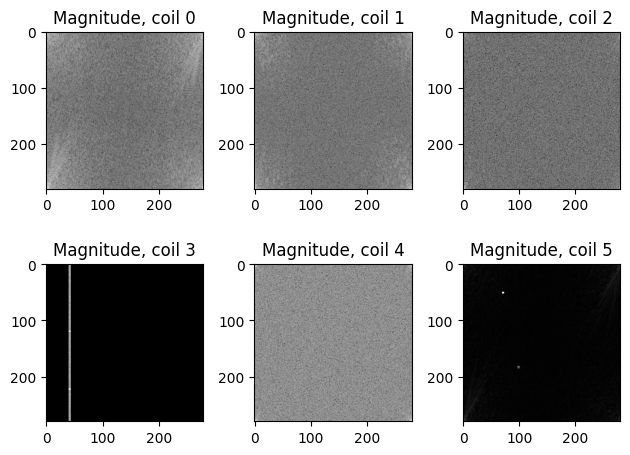

In [4]:
for i in range(kspace.shape[0]):
    plt.subplot(2,3,i+1)
    plt.imshow(np.log1p(np.abs(kspace[i])), cmap="grey")
    plt.title(f"Magnitude, coil {i}")
plt.tight_layout()

### Transpose the data into image space using the Fourier transform. Create and show a magnitude and phase image from one coil.

Text(0.5, 1.0, 'Phase')

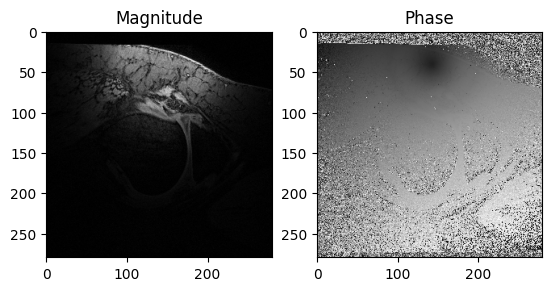

In [5]:
image1 = np.fft.ifft2(kspace[0])

plt.subplot(1,2,1)
plt.imshow(np.abs(image1), cmap="grey")
plt.title("Magnitude")

plt.subplot(1,2,2)
plt.imshow(np.angle(image1), cmap="grey")
plt.title("Phase")

### Show the magnitude images from all coils.

In [6]:
image1 = np.fft.ifft2(kspace[0])
image2 = np.fft.ifft2(kspace[1])
image3 = np.fft.ifft2(kspace[2])
image4 = np.fft.ifft2(kspace[3])
image5 = np.fft.ifft2(kspace[4])
image6 = np.fft.ifft2(kspace[5])

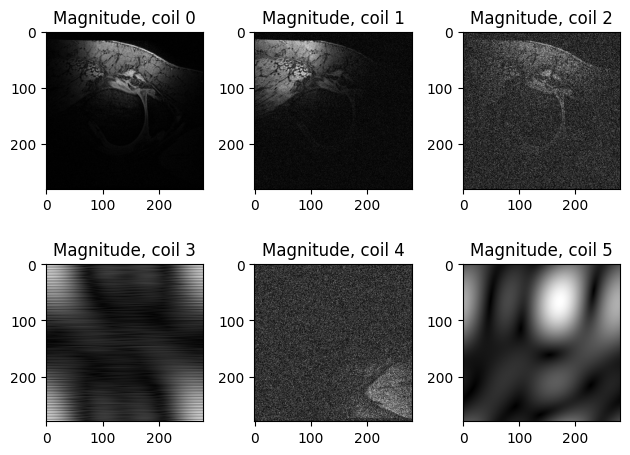

In [7]:
for i in range(kspace.shape[0]):
    plt.subplot(2,3,i+1)
    plt.imshow(np.abs(np.fft.ifft2(kspace[i])), cmap="grey")
    plt.title(f"Magnitude, coil {i}") 
plt.tight_layout()

### Choose an appropriate way to combine the data from all of the coils into a single image (in image space). Do this by squaring the image from each coil, summing the magnitudes, and then taking the square root of the final result. Show this image.

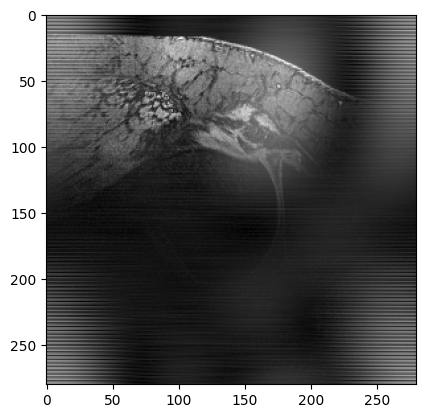

In [8]:
combined_image = np.sqrt(np.abs(image1)**2+np.abs(image2)**2+np.abs(image3)**2+np.abs(image4)**2+np.abs(image5)**2+np.abs(image6)**2)

plt.imshow(combined_image, cmap="grey")

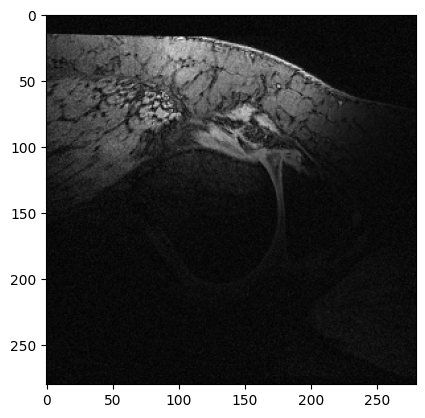

In [9]:
# combining part of coils (1,2,3,5)
part_combined_image = np.sqrt(np.abs(image1)**2+np.abs(image2)**2+np.abs(image3)**2+np.abs(image5)**2)

plt.imshow(part_combined_image, cmap="grey")

### Write about your observations.

This image contains all the information from all 6 coils which we have seen individually above. For example, from 4th coil (coil 3) we get the striped lines, from first 2 we get more of the image structure.

## Exercise 2.2 Removing noise

### Choose three denoising methods using the image space data, and show the effects of the denoising for all coils. Denoising methods can include mean, bilateral, wavelet, or any other filter. A number of filters can be found in scikit-image. "gaussian_filter" can be found in scipy.ndimage. Comment on the different denoising methods

#### Denoising using mean filter

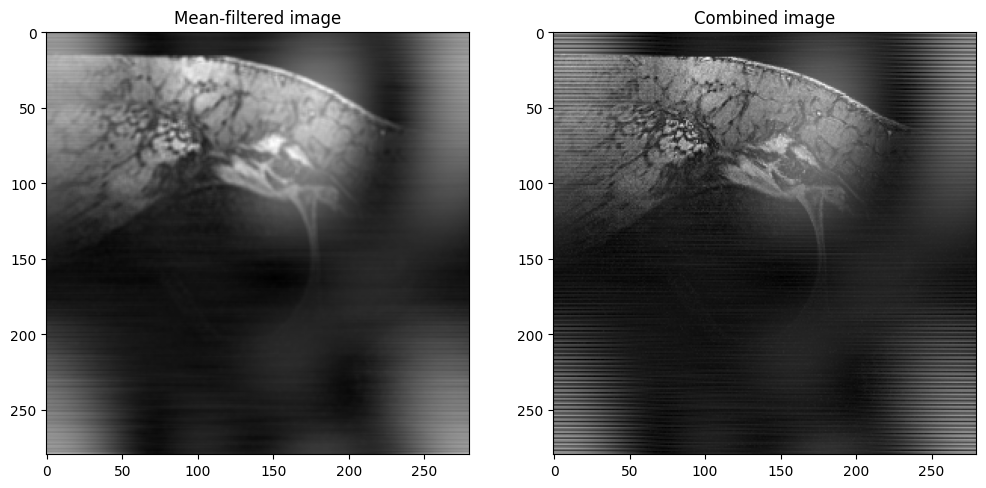

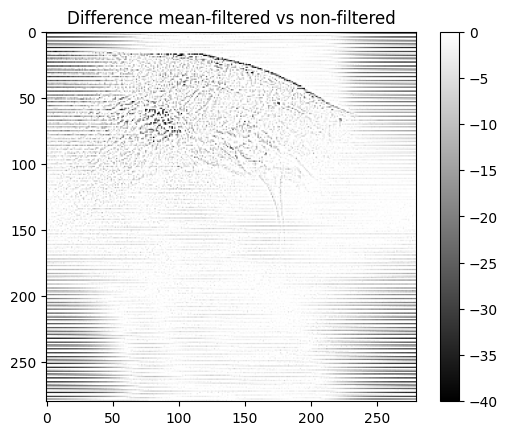

In [10]:
mean_filtered_image = uniform_filter(combined_image, size=3)

plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(np.abs(mean_filtered_image), cmap="grey")
plt.title("Mean-filtered image")

plt.subplot(1,2,2)
plt.imshow(np.abs(combined_image), cmap="grey")
plt.title("Combined image")

plt.figure()
plt.imshow(np.abs(mean_filtered_image)-np.abs(combined_image), cmap="grey")
plt.title("Difference mean-filtered vs non-filtered")
plt.clim(-40,0)
plt.colorbar()

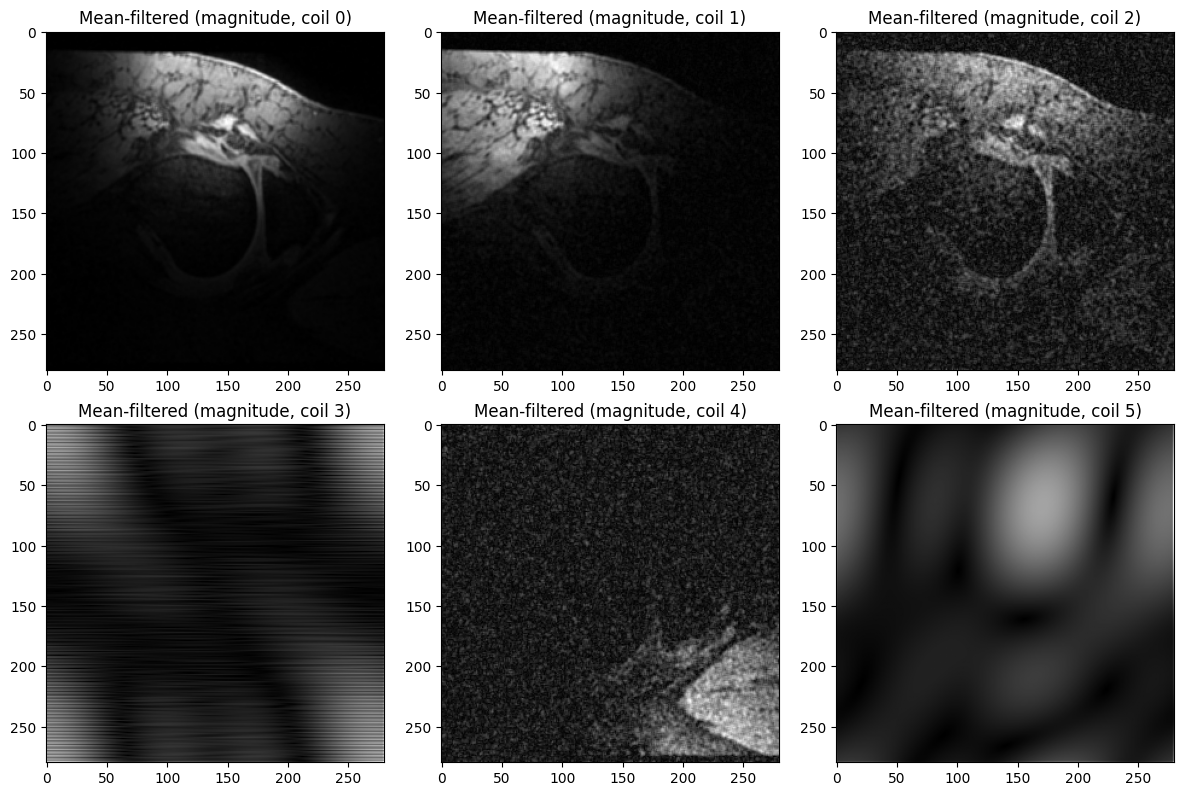

In [11]:
# displaying the result for all coils
plt.figure(figsize=(12,8))
for i in range(kspace.shape[0]):
    plt.subplot(2,3,i+1)
    image_i = np.fft.ifft2(kspace[i])
    plt.imshow(np.abs(uniform_filter(image_i, size=3)), cmap="grey") 
    plt.title(f"Mean-filtered (magnitude, coil {i})") 
plt.tight_layout()

#### Denoising using Gaussian filter

Text(0.5, 1.0, 'Combined image')

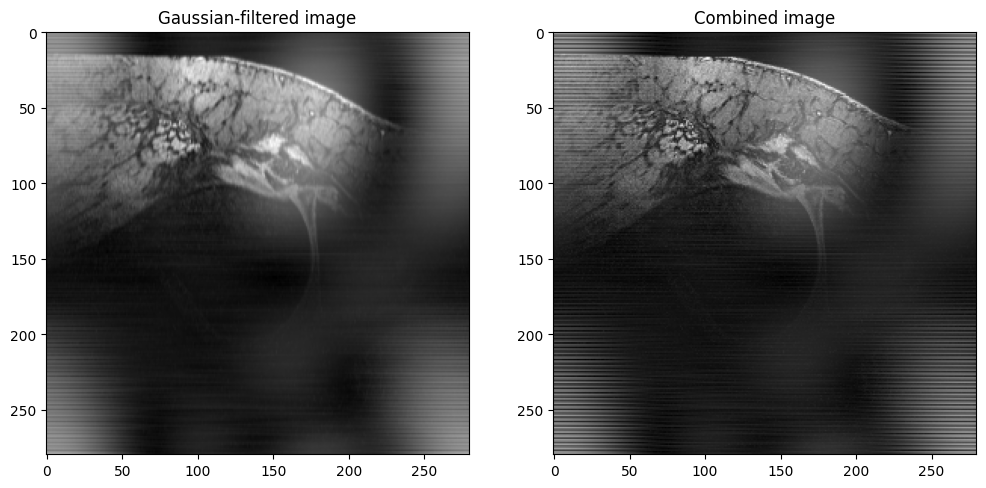

In [12]:
sigma = (0.8, 0.4) # if too high, details are lost

plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(np.abs(gaussian_filter(combined_image, sigma=sigma)), cmap="grey")
plt.title("Gaussian-filtered image")

plt.subplot(1,2,2)
plt.imshow(np.abs(combined_image), cmap="grey")
plt.title("Combined image")

Text(0.5, 1.0, 'In Mean, not in Gaussian filtered images')

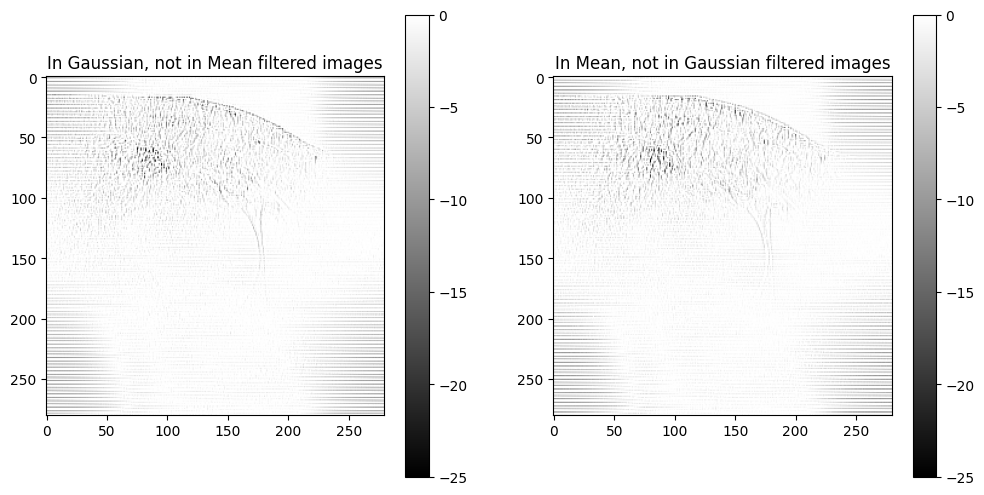

In [13]:
# Gaussian and Mean filters comparison
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.imshow(np.abs(mean_filtered_image) - np.abs(gaussian_filter(combined_image, sigma=sigma)), cmap="grey")
plt.colorbar()
plt.clim(-25,0)
plt.title("In Gaussian, not in Mean filtered images")

plt.subplot(1,2,2)
plt.imshow(np.abs(gaussian_filter(combined_image, sigma=sigma)) - np.abs(mean_filtered_image), cmap="grey")
plt.colorbar()
plt.clim(-25,0)
plt.title("In Mean, not in Gaussian filtered images")

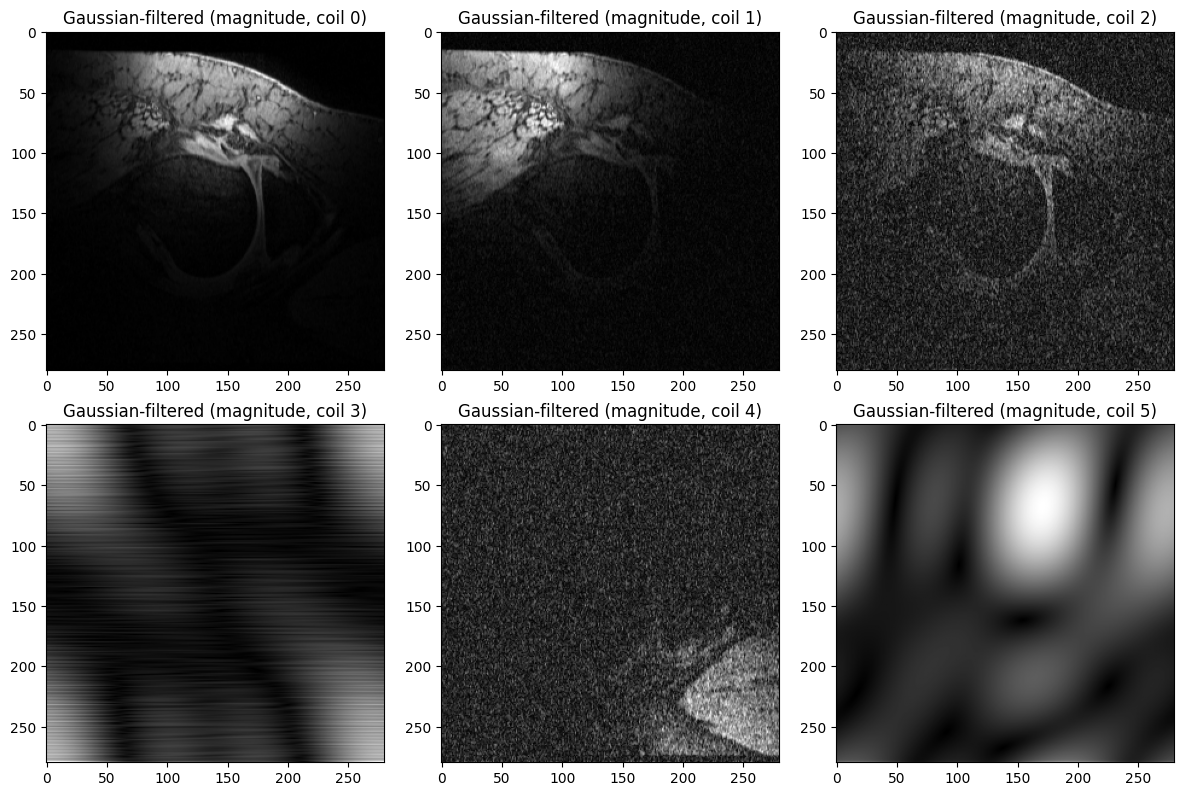

In [14]:
# displaying the result for all coils
plt.figure(figsize=(12,8))
for i in range(kspace.shape[0]):
    plt.subplot(2,3,i+1)
    image_i = np.fft.ifft2(kspace[i])
    plt.imshow(np.abs(gaussian_filter(image_i, sigma=sigma)), cmap="grey") 
    plt.title(f"Gaussian-filtered (magnitude, coil {i})") 
plt.tight_layout()

As well-observed in the difference image, Gaussian filter removes some noise (striped lines) but also some details from the image that are of interest (as it removes all parts where oscillations are of certain strength).

#### Denoising using wavelet filter

Text(0.5, 1.0, 'Difference wavelet-filtered vs non-filtered')

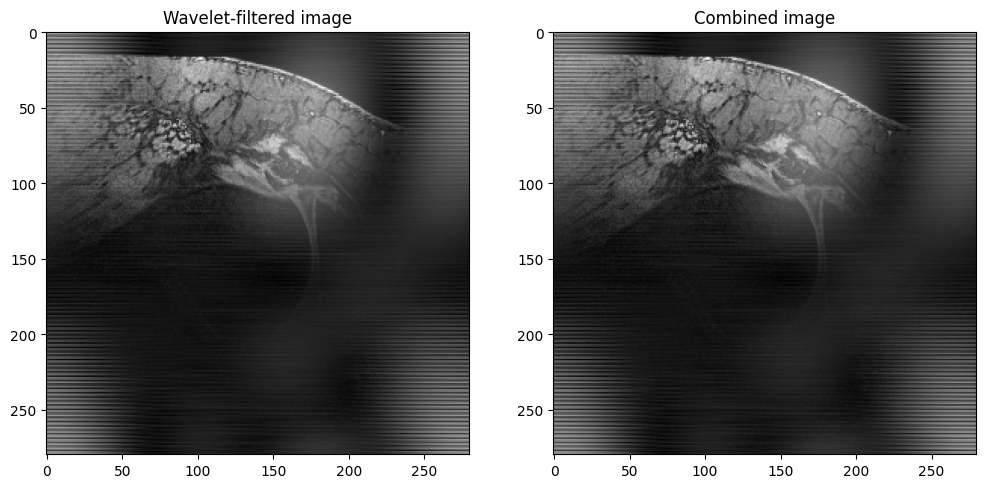

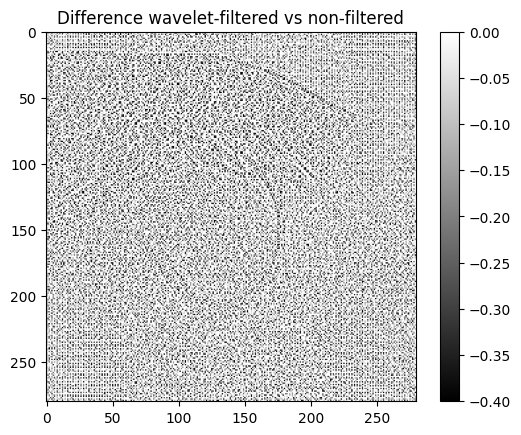

In [15]:
im_bayes = denoise_wavelet(combined_image, channel_axis=None, 
                        method='BayesShrink', mode='soft', rescale_sigma=True)

plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(im_bayes, cmap="grey")
plt.title("Wavelet-filtered image")

plt.subplot(1,2,2)
plt.imshow(np.abs(combined_image), cmap="grey")
plt.title("Combined image")

plt.figure()
plt.imshow(np.abs(im_bayes) - np.abs(combined_image), cmap="grey")
plt.colorbar()
plt.clim(-0.4,0)
plt.title("Difference wavelet-filtered vs non-filtered")

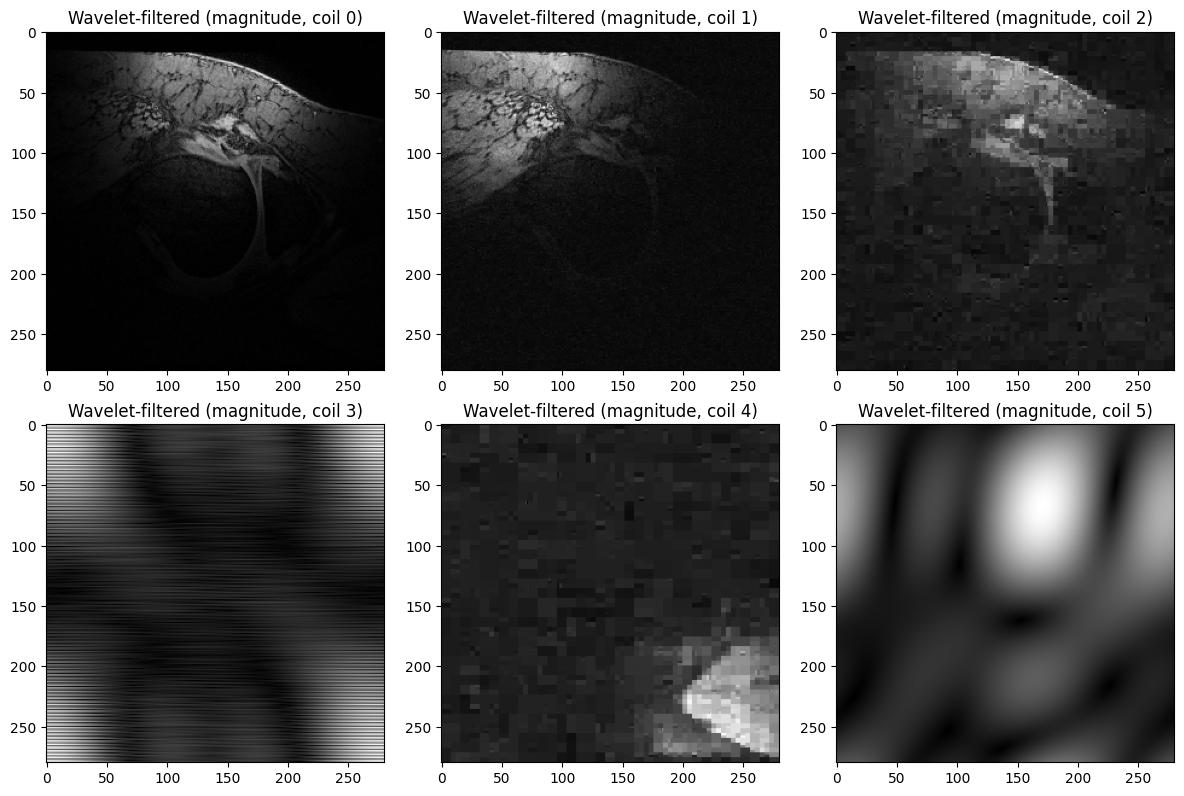

In [16]:
# displaying the result for all coils
plt.figure(figsize=(12,8))
for i in range(kspace.shape[0]):
    plt.subplot(2,3,i+1)
    image_i = np.fft.ifft2(kspace[i])
    plt.imshow(denoise_wavelet(np.abs(image_i), channel_axis=None, method='BayesShrink', mode='soft', rescale_sigma=True),
                cmap="grey") 
    plt.title(f"Wavelet-filtered (magnitude, coil {i})") 
plt.tight_layout()

Should improve the quality of image by reducing noise, but seems like it became a bit more blurry. However, the difference image does suggest noise reduction as well as good edge preservation.

#### Denoising using Farid transform

Text(0.5, 1.0, 'Difference image')

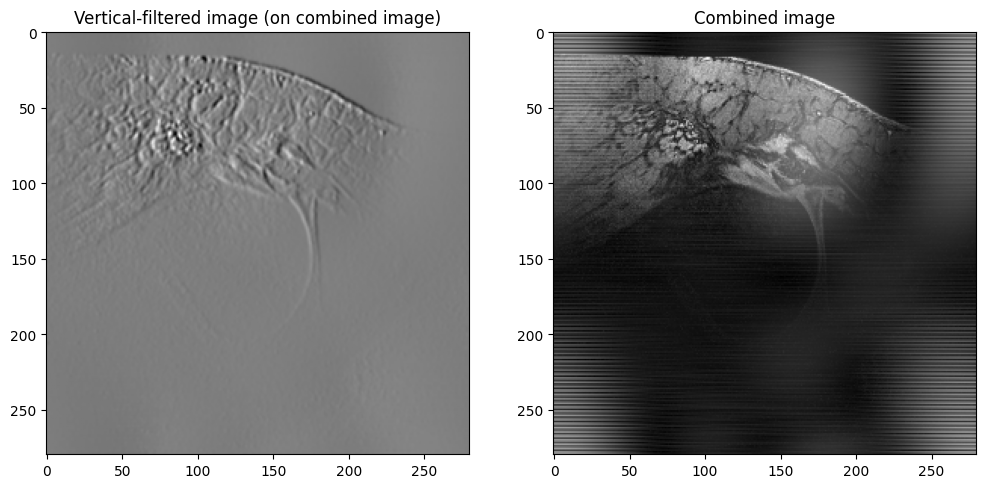

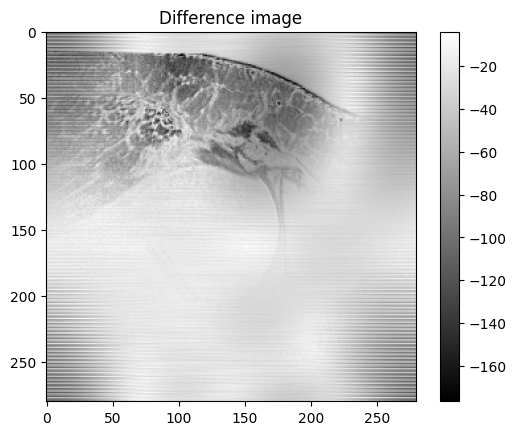

In [17]:
from skimage.filters import farid_v

farid_image = farid_v(combined_image)

plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(farid_image, cmap="grey")
plt.title("Vertical-filtered image (on combined image)")

plt.subplot(1,2,2)
plt.imshow(combined_image, cmap="grey")
plt.title("Combined image")

plt.figure()
plt.imshow(farid_image - combined_image, cmap="grey")
plt.colorbar()
plt.title("Difference image")

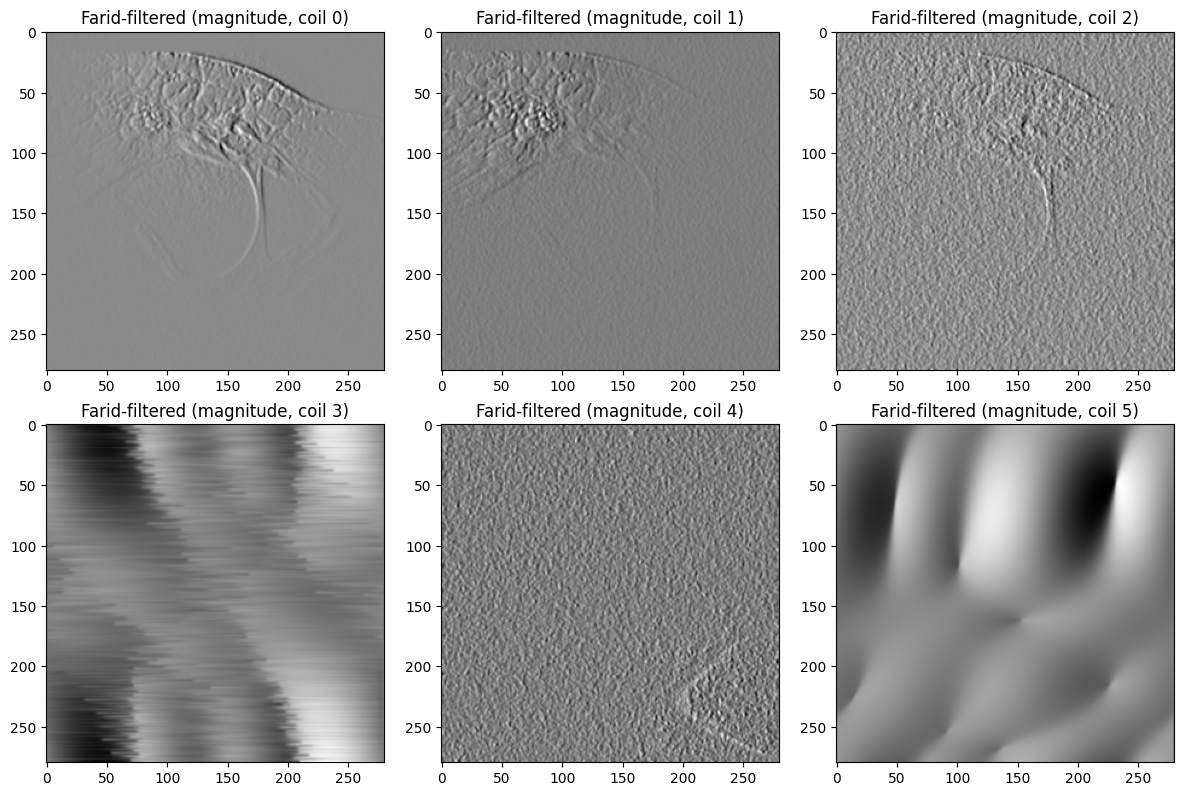

In [18]:
# displaying the result for all coils
plt.figure(figsize=(12,8))
for i in range(kspace.shape[0]):
    plt.subplot(2,3,i+1)
    image_i = np.fft.ifft2(kspace[i])
    plt.imshow(farid_v(np.abs(image_i)), cmap="grey") 
    plt.title(f"Farid-filtered (magnitude, coil {i})") 
plt.tight_layout()

This method finds the vertical edges of an image using the Farid transform. It is useful in displaying the structure and getting rid of the horizontal lines (noise in this case). It is a very bad idea to use this filter on an image from coli 3 (with Gaussian noise).

#### Denoising using bilateral filter

Text(0.5, 1.0, 'Difference image')

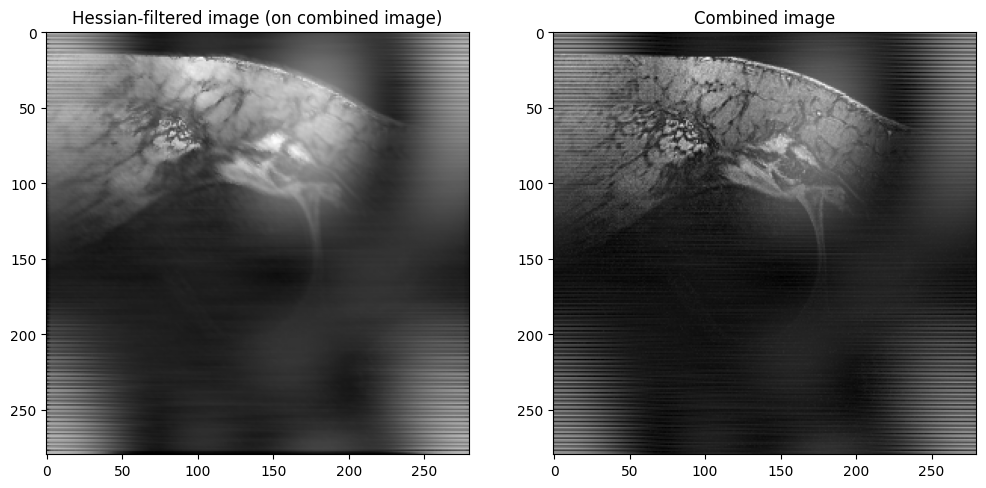

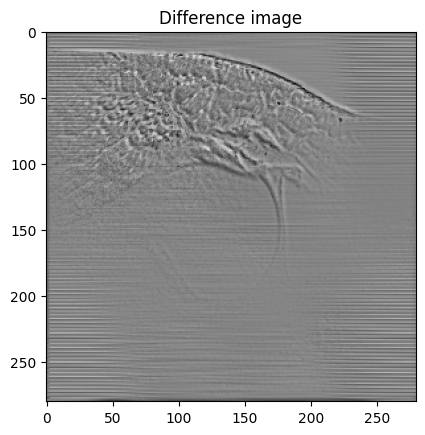

In [19]:
from skimage.restoration import denoise_bilateral

denoise_bilateral_image = denoise_bilateral(combined_image)

plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(denoise_bilateral_image, cmap="grey")
plt.title("Hessian-filtered image (on combined image)")

plt.subplot(1,2,2)
plt.imshow(combined_image, cmap="grey")
plt.title("Combined image")

plt.figure()
plt.imshow(denoise_bilateral_image - combined_image, cmap="grey")
plt.title("Difference image")

Similar in logic to Gaussian filter, the Hessian filter uses Hessian to correct for noise. However, it does not seem as useful in this case.

#### Denoising using median filter

Text(0.5, 1.0, 'Difference image')

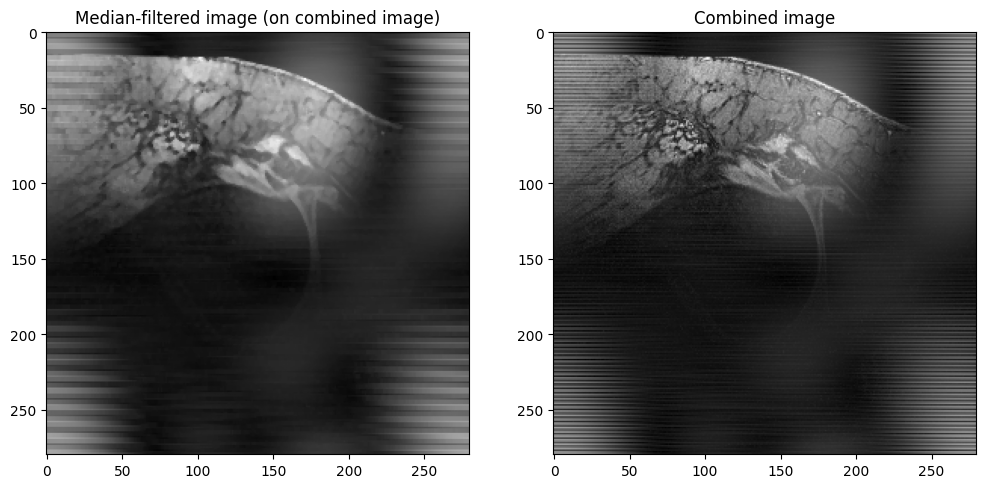

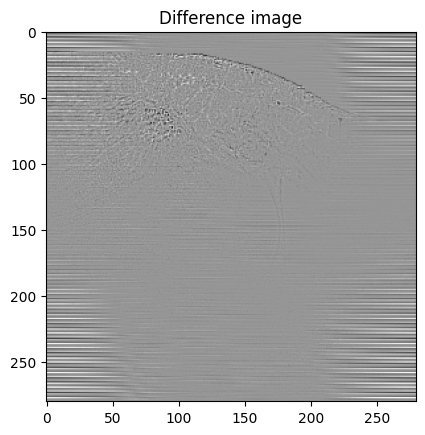

In [20]:
median_image = median_filter(combined_image, 3)

plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(np.abs(median_image), cmap="grey")
plt.title("Median-filtered image (on combined image)")

plt.subplot(1,2,2)
plt.imshow(np.abs(combined_image), cmap="grey")
plt.title("Combined image")

plt.figure()
plt.imshow(np.abs(median_image) - np.abs(combined_image), cmap="grey")
plt.title("Difference image")

Overall, it is really important to know which type of noise we are expecting to correct for. THis information would drive the specific filter usage which would improve the image the most.

### Start from the original noisy k-space. For the first coil, apply a low-pass Butterworth filter within k-space and show the new image, showing both magnitude and phase images. How does this denoising method compare to the image-based methods?

In [21]:
# defining the filter
def butterworth_lowpass_filter(shape, D0=30, n=2): 
    """
    Generate a Butterworth low-pass filter.
        
    This function creates a 2D Butterworth low-pass filter that can be 
    applied to k-space data. The filter is parameterized by a cutoff frequency (D0)
    and the order of the filter (n).

    Parameters:
    shape: tuple
        A tuple representing the shape of the filter, corresponding to the dimensions 
        of the input k-space data (rows,columns).
        
    D0: float, optional
        The cutoff frequency of the filter. Default value is 30.
        
    n: int, optional
        The order of the Butterworth filter. Default is 2.

    Returns:
    --------
    H : ndarray
        A 2D NumPy array of the same shape as the input shape containing the 
        Butterworth low-pass filter coefficients. Values close to 1 correspond 
        to passing frequencies, while values close to 0 correspond to attenuated 
        frequencies.

    Example:
    >>> butterworth_filter = butterworth_lowpass_filter(kspace[0].shape)
        """
    P, Q = shape[0], shape[1]
    u = np.arange(P) - P // 2 #creates an array u that contains values from -P//2 to P//2-1
    v = np.arange(Q) - Q // 2
    U, V = np.meshgrid(u, v, indexing='ij') 
    D = np.sqrt(U**2 + V**2)
    H = 1 / (1 + (D / D0) ** (2 * n)) 
    return H #values of H close to 1 correspond to frequencies that will pass through

In [22]:
# trying to understand where to cut off
print(np.min(np.abs(kspace[0])))
print(np.max(np.abs(kspace[0])))
print(np.mean(np.abs(kspace[0])))
print(np.mean(np.abs(kspace[3])))

0.9882094241282626
787579.5146888812
1656.4226786507031
225.88009859075913


Text(0.5, 1.0, 'Phase image')

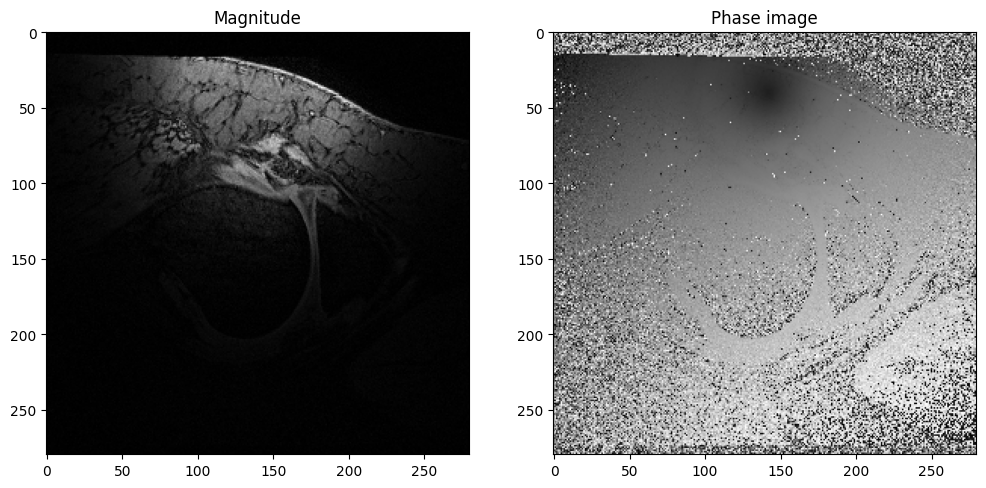

In [58]:
#applying the filter and visualizing results
butterworth_filter = butterworth_lowpass_filter(kspace[0].shape, D0=300)

butterw_filtered_k = kspace[0] * butterworth_filter

butterw_filtered_im = np.fft.ifft2(butterw_filtered_k)

plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(np.abs(butterw_filtered_im), cmap="grey")
plt.title("Magnitude")

plt.subplot(1,2,2)
plt.imshow(np.angle(butterw_filtered_im), cmap="grey")
plt.title("Phase image")

Text(0.5, 1.0, 'Filtered')

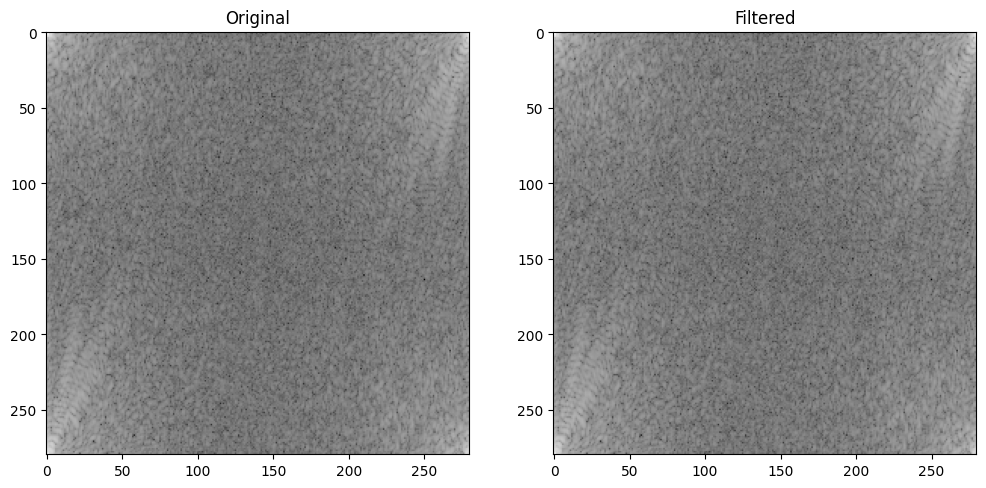

In [59]:
plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(np.log1p(np.abs(kspace[0])), cmap="grey")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(np.log1p(np.abs(butterw_filtered_k)), cmap="grey")
plt.title("Filtered")

Text(0.5, 1.0, 'Original')

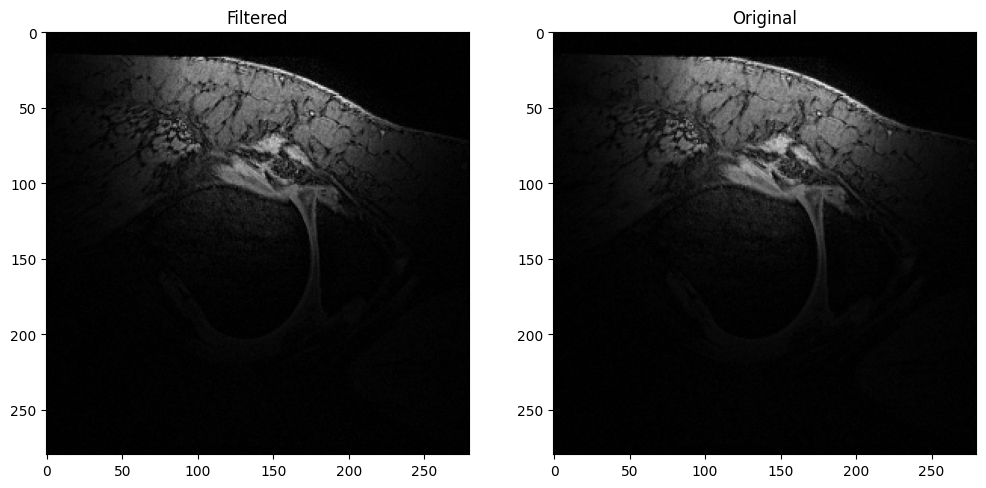

In [60]:
plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(np.abs(butterw_filtered_im), cmap="grey")
plt.title("Filtered")

plt.subplot(1,2,2)
plt.imshow(np.abs(np.fft.ifft2(kspace[0])), cmap="grey")
plt.title("Original")

Text(0.5, 1.0, 'Phase image')

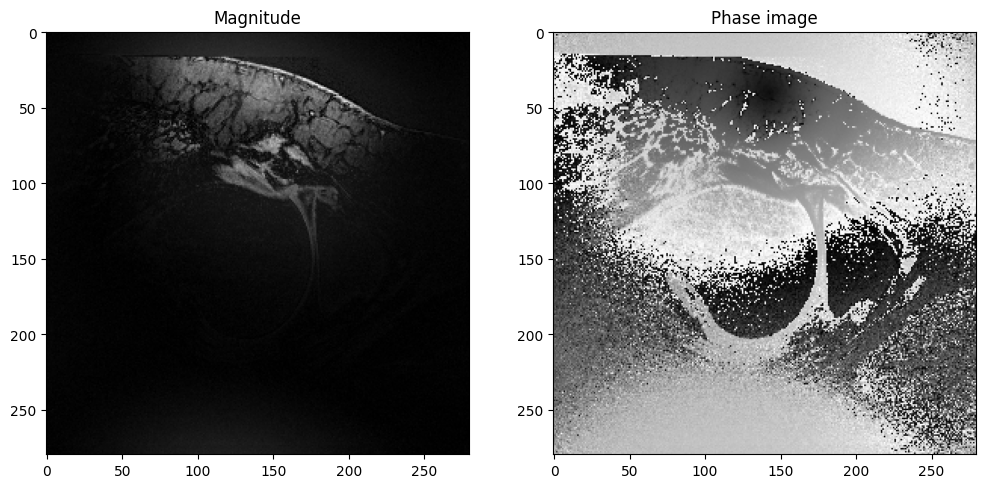

In [24]:
#using skimage implementation for this filter
from skimage.filters import butterworth
filt_btw_coil1 = butterworth(image1)

plt.figure(figsize=(12, 6)) 
plt.subplot(1,2,1)
plt.imshow(np.abs(filt_btw_coil1), cmap="grey")
plt.title("Magnitude")

plt.subplot(1,2,2)
plt.imshow(np.angle(filt_btw_coil1), cmap="grey")
plt.title("Phase image")

Frequency Domain vs. Image Domain: Filtering k-space directly utilizes frequency domain information, which can effectively suppress high-frequency noise components, while preserving lower-frequency components that represent actual image features.

Edge Preservation: Image-based methods may struggle with preserving fine details or edges, especially when using smoothing techniques. Fourier-based filtering can maintain edges while removing noise.

Computational Efficiency: Direct k-space filtering might be more efficient for large datasets compared to performing denoising after imaging, as it handles multiple spatial frequencies simultaneously.

### Using one of denoising methods on the images, recreate a new combined image.

Text(0.5, 1.0, 'New combined - old combined')

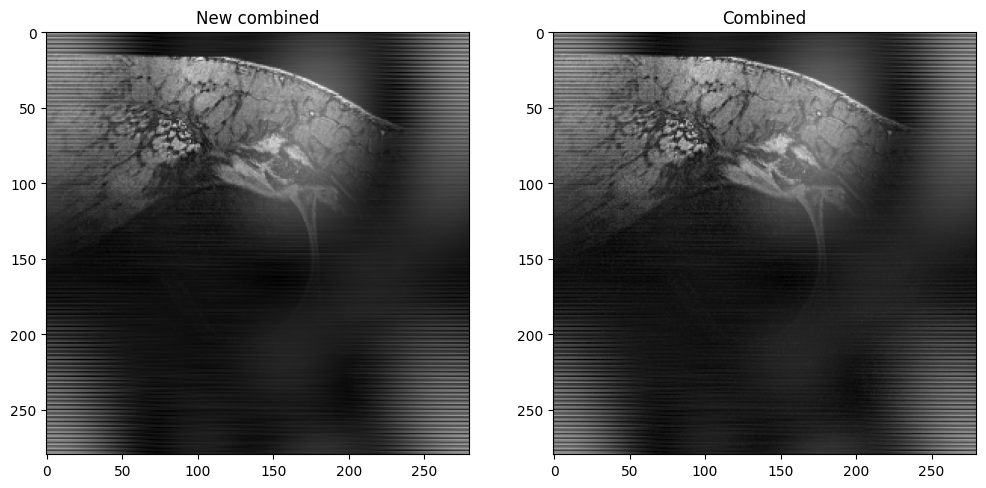

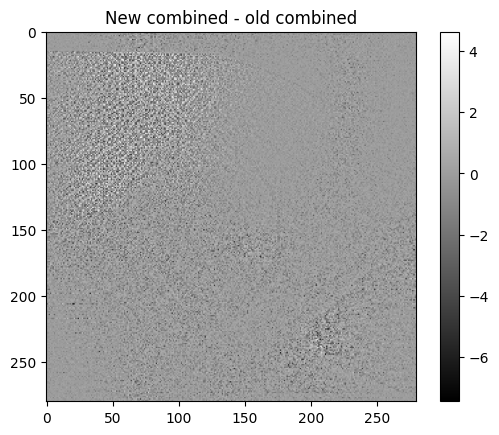

In [25]:
w_denoised_coil1 = denoise_wavelet(np.abs(np.fft.ifft2(kspace[0])), channel_axis=None, method='BayesShrink', mode='soft', rescale_sigma=True) 
w_denoised_coil2 = denoise_wavelet(np.abs(np.fft.ifft2(kspace[1])), channel_axis=None, method='BayesShrink', mode='soft', rescale_sigma=True) 
w_denoised_coil3 = denoise_wavelet(np.abs(np.fft.ifft2(kspace[2])), channel_axis=None, method='BayesShrink', mode='soft', rescale_sigma=True) 
w_denoised_coil4 = denoise_wavelet(np.abs(np.fft.ifft2(kspace[3])), channel_axis=None, method='BayesShrink', mode='soft', rescale_sigma=True) 
w_denoised_coil5 = denoise_wavelet(np.abs(np.fft.ifft2(kspace[4])), channel_axis=None, method='BayesShrink', mode='soft', rescale_sigma=True) 
w_denoised_coil6 = denoise_wavelet(np.abs(np.fft.ifft2(kspace[5])), channel_axis=None, method='BayesShrink', mode='soft', rescale_sigma=True) 


# combining filtered images into one
new_combined_im = np.sqrt(np.abs(w_denoised_coil1)**2+np.abs(w_denoised_coil2)**2+
                        np.abs(w_denoised_coil3)**2+np.abs(w_denoised_coil4)**2+
                        np.abs(w_denoised_coil5)**2+np.abs(w_denoised_coil6)**2)

plt.figure(figsize=(12, 8)) 
plt.subplot(1,2,1)
plt.imshow(new_combined_im, cmap="gray")
plt.title("New combined")

plt.subplot(1,2,2)
plt.imshow(combined_image, cmap="gray")
plt.title("Combined")

plt.figure() 
plt.imshow(new_combined_im - combined_image, cmap="gray")
plt.colorbar()
plt.title("New combined - old combined")

#### Butterworth filter and combining

In [26]:
def apply_butterworth_lowpass_filter(kspace, D0=300, n=2):
    """
    Apply a Butterworth low-pass filter to k-space data.

    This function applies Butterworth low-pass filter to the k-space data
    to attenuate high-frequency components. Then performs an inverse Fourier 
    transform to obtain the filtered image.

    Parameters:
    kspace: ndarray
        The 2D array of k-space data for an image (complex values).
        
    D0: float, optional
        The cutoff frequency for the Butterworth filter. Default is 300.

    n: int, optional
        The order of the Butterworth filter. Default is 2.

    Returns:
    ndarray: The magnitude of the filtered image in the spatial domain.
    """
    btwf = butterworth_lowpass_filter(kspace.shape, D0=D0, n=n)
    butterw_filtered = kspace * btwf
    butterw_filtered_im = np.fft.ifft2(butterw_filtered)
    return np.abs(butterw_filtered_im)

Text(0.5, 1.0, 'New combined - old combined')

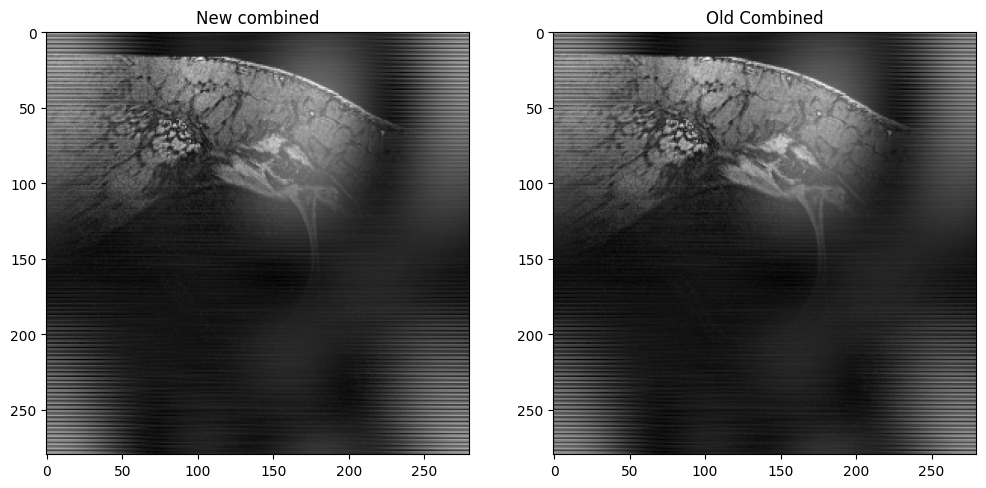

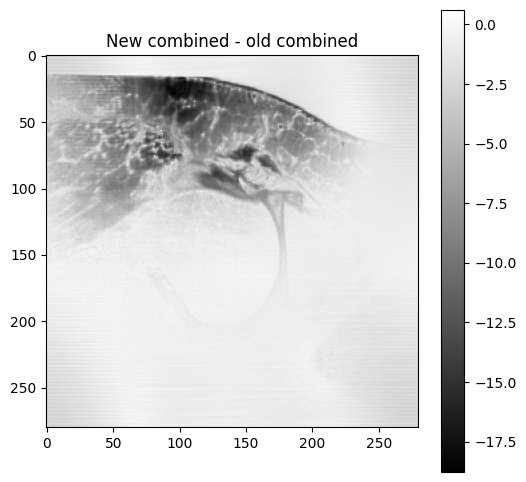

In [27]:
#applying the filter to each coil
butterw_filtered_im1 = apply_butterworth_lowpass_filter(kspace[0], D0=300)
butterw_filtered_im2 = apply_butterworth_lowpass_filter(kspace[1], D0=300)
butterw_filtered_im3 = apply_butterworth_lowpass_filter(kspace[2], D0=300)
butterw_filtered_im4 = apply_butterworth_lowpass_filter(kspace[3], D0=300)
butterw_filtered_im5 = apply_butterworth_lowpass_filter(kspace[4], D0=300)
butterw_filtered_im6 = apply_butterworth_lowpass_filter(kspace[5], D0=300)

# combining filtered images into one
new_combined_im = np.sqrt(np.abs(butterw_filtered_im1)**2+np.abs(butterw_filtered_im2)**2+
                        np.abs(butterw_filtered_im3)**2+np.abs(butterw_filtered_im4)**2+
                        np.abs(butterw_filtered_im5)**2+np.abs(butterw_filtered_im6)**2)

plt.figure(figsize=(12, 8)) 
plt.subplot(1,2,1)
plt.imshow(new_combined_im, cmap="gray")
plt.title("New combined")

plt.subplot(1,2,2)
plt.imshow(combined_image, cmap="gray")
plt.title("Old Combined")

plt.figure(figsize=(6, 6)) 
plt.imshow(new_combined_im - combined_image, cmap="gray")
plt.colorbar()
plt.title("New combined - old combined")